 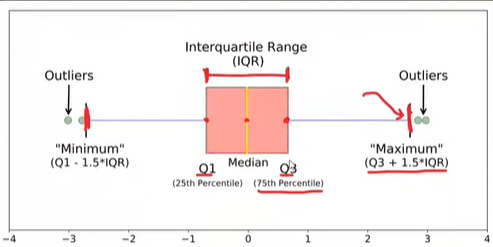

In [1]:
# Values lying out side max and min are outliers
# this method is used for skewed distributions
# method called IQR proximity rule
# find q1 q3 IQR and eliminate using trim or capping

In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv('placement.csv',usecols=['placement_exam_marks'])

In [5]:
df.sample(3)

,placement_exam_marks
789,74.0
372,8.0
214,60.0


In [6]:
import seaborn as sns

<Axes: ylabel='placement_exam_marks'>

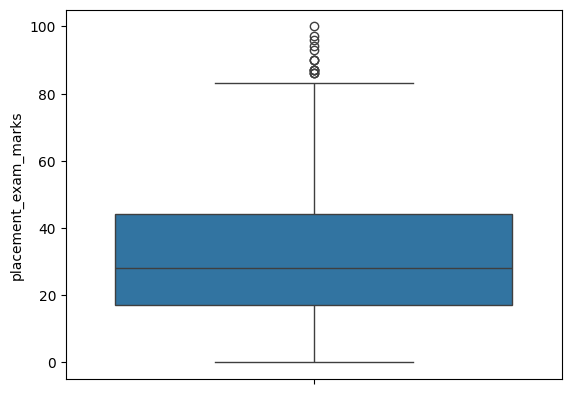

In [7]:
sns.boxplot(df['placement_exam_marks'])

In [8]:
df.describe()

,placement_exam_marks
count,1000.000000
mean,32.225000
std,19.130822
min,0.000000
25%,17.000000
50%,28.000000
75%,44.000000
max,100.000000


In [21]:
Q1=df['placement_exam_marks'].quantile(0.25)
Q3=df['placement_exam_marks'].quantile(0.75)
IQR=Q3-Q1

In [22]:
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR

In [23]:
# Trimming
df1=df[(df['placement_exam_marks']>lower_limit) & (df['placement_exam_marks']<upper_limit)]

In [24]:
df1.shape

(985, 1)

In [25]:
df1.describe()

,placement_exam_marks
count,985.000000
mean,31.339086
std,17.857633
min,0.000000
25%,17.000000
50%,28.000000
75%,43.000000
max,83.000000


In [26]:
# capping:
df2=np.where(
    df['placement_exam_marks']<lower_limit ,lower_limit,(
        np.where(df['placement_exam_marks']>upper_limit,upper_limit,df['placement_exam_marks'])
    
    )
)

In [27]:
df2=pd.DataFrame(df2,columns=['placement_exam_marks'])
print(lower_limit,upper_limit)

-23.5 84.5


In [28]:
df2.describe()

,placement_exam_marks
count,1000.000000
mean,32.136500
std,18.865419
min,0.000000
25%,17.000000
50%,28.000000
75%,44.000000
max,84.500000


<Axes: >

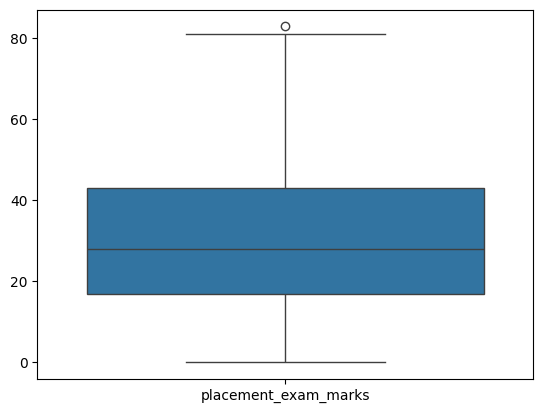

In [29]:
sns.boxplot(df1)

<Axes: >

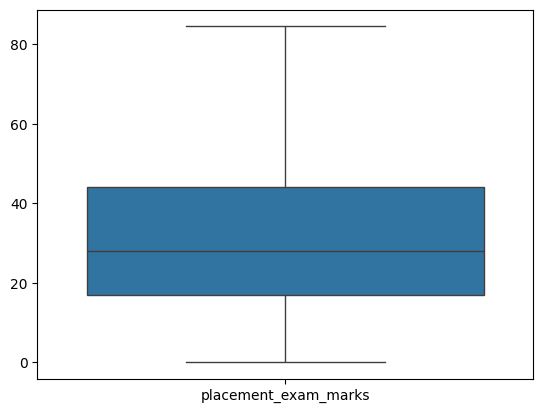

In [32]:
sns.boxplot(df2)

In [31]:
df2

,placement_exam_marks
0,26.0
1,38.0
2,40.0
3,8.0
4,17.0
...,...
995,44.0
996,65.0
997,34.0
998,46.0
